# Description

It explores the context/tissue/cell type of the top samples associated with an LV.

Follow the notebook instructions below.

# Modules

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.recount2 import LVAnalysis
from utils import chunker
import conf

# Settings

Specify below the LV id you are interested in:

In [2]:
LV_NAME = "LV918"

# Paths

These are paths to folder and files where we'll save our figures.

In [3]:
OUTPUT_FIGURES_DIR = Path(conf.RESULTS_DIR, "demo", f"{LV_NAME.lower()}").resolve()
display(OUTPUT_FIGURES_DIR)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PosixPath('/opt/data/results/demo/lv918')

In [4]:
OUTPUT_CELL_TYPE_FILEPATH = OUTPUT_FIGURES_DIR / f"{LV_NAME.lower()}-cell_types.svg"
display(OUTPUT_CELL_TYPE_FILEPATH)

PosixPath('/opt/data/results/demo/lv918/lv918-cell_types.svg')

# Load MultiPLIER summary

In [5]:
multiplier_model_summary = pd.read_pickle(conf.MULTIPLIER["MODEL_SUMMARY_FILE"])

In [6]:
multiplier_model_summary.shape

(2157, 5)

In [7]:
multiplier_model_summary.head()

,pathway,LV index,AUC,p-value,FDR
1,KEGG_LYSINE_DEGRADATION,1,0.388059,0.866078,0.956005
2,REACTOME_MRNA_SPLICING,1,0.733057,0.000048,0.000582
3,MIPS_NOP56P_ASSOCIATED_PRE_RRNA_COMPLEX,1,0.680555,0.001628,0.011366
4,KEGG_DNA_REPLICATION,1,0.549473,0.312155,0.539951
5,PID_MYC_ACTIVPATHWAY,1,0.639303,0.021702,0.083739


# Load LV data

You can use the `LVAnalysis` class to explore an LV.

In [8]:
lv_obj = LVAnalysis(LV_NAME)

Here I show the top 20 genes for our LV. You can see gene symbols, the LV weight (in column `LV603`) and the cytoband.

In [9]:
lv_obj.lv_genes.head(20)

,gene_name,LV918,gene_band
0,WNT2B,3.666354,1p13.2
1,WNT1,3.491647,12q13.12
2,CSNK1A1L,3.428269,13q13.3
3,PTCH2,3.143229,1p34.1
4,PRKACG,2.624187,9q21.11
5,BMP4,2.608283,14q22.2
6,WNT10B,2.607508,12q13.12
7,GLI1,2.590445,12q13.3
8,BMP8A,2.586245,1p34.3
9,SUFU,2.555121,10q24.32


Show the pathways our LV is aligned to (neutrophils):

In [10]:
multiplier_model_summary[
    multiplier_model_summary["LV index"].isin((LV_NAME[2:],))
    & (
        (multiplier_model_summary["FDR"] < 0.05)
        & (multiplier_model_summary["AUC"] >= 0.75)
    )
]

[2025-09-24 15:04:56,587 - numexpr.utils] INFO: Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
[2025-09-24 15:04:56,587 - numexpr.utils] INFO: NumExpr defaulting to 8 threads.


,pathway,LV index,AUC,p-value,FDR


Here I load the LV metadata.
This is, for each sample from our matrix B, we load its metadata.
The `LVAnalysis` class takes care of downloading all necessary files from recount2.

In [11]:
lv_data = lv_obj.get_experiments_data()

SRP042161, SRP066834, SRP041179, SRP057196, SRP055569, SRP055513, SRP061801, SRP017575, SRP050499, SRP055153, SRP012461, SRP003754, SRP060416, SRP058773, SRP013402, SRP059775, SRP019994, SRP053195, SRP007596, SRP036821, SRP006575, SRP000599, SRP005279, SRP009247, SRP007412, SRP043221, SRP067469, SRP002487, SRP006474, SRP057205, SRP052056, SRP030617, SRP014487, SRP006769, SRP045222, SRP056041, SRP004637, SRP017972, SRP014009, SRP049436, SRP008775, SRP014320, SRP015976, SRP047194, SRP009266, SRP044925, SRP026537, SRP018853, SRP027015, SRP012099, SRP033135, SRP058740, SRP017411, SRP023262, SRP012098, SRP064259, SRP058120, SRP033464, SRP034528, SRP002079, SRP025982, SRP010483, SRP045308, SRP002184, SRP049409, SRP002326, SRP043320, SRP017777, SRP045294, SRP027364, SRP047476, SRP035268, SRP042184, SRP007494, SRP034011, SRP015711, SRP018020, SRP063339, SRP059692, SRP027530, SRP049820, SRP065219, SRP007461, SRP001758, SRP048761, SRP041833, SRP007506, SRP008331, SRP063493, SRP050179, SRP049823,

/opt/code/libs/data/recount2.py:323: UserWarning: Not all experiments data could be loaded (88 != 92)
  warnings.warn(


In [12]:
lv_data.shape

(8794, 159)

In [13]:
lv_data.head()

cell line     cell type patient id subtype Stage tissue  \
project   run                                                                  
SRP042161 SRR1294536       NaN  Glioblastoma      MGH26     NaN   NaN    NaN   
          SRR1294537       NaN  Glioblastoma      MGH26    None   NaN    NaN   
          SRR1294538       NaN  Glioblastoma      MGH26     NaN   NaN    NaN   
          SRR1294539       NaN  Glioblastoma      MGH26     NaN   NaN    NaN   
          SRR1294540       NaN  Glioblastoma      MGH26     NaN   NaN    NaN   

                     run id  age c1 chip id experiment_sample_name  ...  \
project   run                                                       ...   
SRP042161 SRR1294536    NaN  NaN        NaN                    NaN  ...   
          SRR1294537    NaN  NaN        NaN                    NaN  ...   
          SRR1294538    NaN  NaN        NaN                    NaN  ...   
          SRR1294539    NaN  NaN        NaN                    NaN  ...   
          SRR1294540    NaN  NaN        NaN                    NaN  ...   

                     rna-seq library preparation kit mrna input  \
project   run                                                     
SRP042161 SRR1294536                             NaN        NaN   
          SRR1294537                             NaN        NaN   
          SRR1294538                             NaN        NaN   
          SRR1294539                             NaN        NaN   
          SRR1294540                             NaN        NaN   

                     sf3b1 mutation age category population doublings serum  \
project   run                                                                 
SRP042161 SRR1294536            NaN          NaN                  NaN   NaN   
          SRR1294537            NaN          NaN                  NaN   NaN   
          SRR1294538            NaN          NaN                  NaN   NaN   
          SRR1294539            NaN          NaN                  NaN   NaN   
          SRR1294540            NaN          NaN                  NaN   NaN   

                     strain targeted by condition     LV918  
project   run                                                
SRP042161 SRR1294536    NaN         NaN       NaN  0.052256  
          SRR1294537    NaN         NaN       NaN -0.012246  
          SRR1294538    NaN         NaN       NaN -0.011499  
          SRR1294539    NaN         NaN       NaN -0.037533  
          SRR1294540    NaN         NaN       NaN -0.119395  

[5 rows x 159 columns]

# LV cell types analysis

## Get top attributes

Here I quickly show the top attributes in our metadata for which we have the largest LV variance.
This is just to have an idea of the variance across different attributes

In [14]:
lv_attrs = lv_obj.get_attributes_variation_score()
display(lv_attrs.head(20))

run id                    0.047367
sirna knock down          0.028552
transfection              0.018295
time of analysis          0.017612
localication              0.017612
donor                     0.017612
sample source             0.016965
experimental_condition    0.016209
sirna                     0.016209
r1_inline_randommer       0.013856
target_gene               0.013856
expression_construct      0.013856
rna associated            0.012654
gestational age           0.011221
trimester                 0.011221
Sex                       0.008886
bcp all subtype           0.008721
lane#                     0.008447
source                    0.008043
tissue subtype            0.008043
dtype: float64

Since we are interested in cell types and tissues, the code below will find which attributes contain "cell type" or "tissue", so we can select from these results.

In [15]:
# show those with cell type or tissue in their name
_tmp = pd.Series(lv_attrs.index)
lv_attrs[
    _tmp.str.match(
        "(?:cell.*(type|line)$)|(?:tissue$)|(?:tissue.*type$)",
        case=False,
        flags=re.IGNORECASE,
    ).values
].sort_values(ascending=False)

tissue subtype    0.008043
tissue            0.004930
cell type         0.004210
cell line         0.004102
cell line/type    0.002020
dtype: float64

Select from the output above those you are interested in. Usually all of them.

In [16]:
lv_attrs_selected = [
    "tissue subtype",
    "tissue",
    "cell type",
    "cell type",
    "cell line/type",
]

In [17]:
_tmp = lv_data.loc[
    :,
    lv_attrs_selected + [LV_NAME],
]

In [18]:
_tmp_seq = list(chunker(_tmp.sort_values(LV_NAME, ascending=False), 25))

Now that we selected attributes that might be providing information about the cell type, we can see which are the top ones.

If you change the number in the cell below, you can paginate over the entire set of results; for example, with `_tmp_seq[1]` you'll see the next "page" in a descending order with respect to the LV value. So the ones at the top are the most important ones.

In [19]:
_tmp_seq[0]

tissue subtype                               tissue  \
project   run                                                              
SRP042161 SRR1294792            NaN                                  NaN   
SRP066834 SRR2967245            NaN  Dissociated whole cerebral organoid   
SRP042161 SRR1294863            NaN                                  NaN   
SRP041179 SRR1238522            NaN                                  NaN   
          SRR1238520            NaN                                  NaN   
SRP057196 SRR1974768            NaN                               cortex   
SRP041179 SRR1238521            NaN                                  NaN   
SRP055569 SRR2019207            NaN                                  NaN   
          SRR1821451            NaN                                  NaN   
SRP055513 SRR1818577            NaN                          endometrium   
SRP061801 SRR2134624            NaN                                  NaN   
SRP041179 SRR1238519            NaN                                  NaN   
SRP017575 SRR633577             NaN                          Soft Tissue   
SRP061801 SRR2134622            NaN                                  NaN   
SRP050499 SRR2013740            NaN                                  NaN   
SRP055153 SRR1810658            NaN                                  NaN   
SRP061801 SRR2134623            NaN                                  NaN   
SRP041179 SRR1238498            NaN                                  NaN   
SRP012461 SRR490287             NaN                                  NaN   
SRP055569 SRR2018970            NaN                                  NaN   
SRP055513 SRR1818521            NaN                          endometrium   
SRP061801 SRR2134625            NaN                                  NaN   
SRP055569 SRR1821672            NaN                                  NaN   
SRP061801 SRR2134570            NaN                                  NaN   
SRP041179 SRR1238502            NaN                                  NaN   

                                                              cell type  \
project   run                                                             
SRP042161 SRR1294792                                       Glioblastoma   
SRP066834 SRR2967245                                                NaN   
SRP042161 SRR1294863                                       Glioblastoma   
SRP041179 SRR1238522                                       hESC (WA-09)   
          SRR1238520                                       hESC (WA-09)   
SRP057196 SRR1974768                                        endothelial   
SRP041179 SRR1238521                                       hESC (WA-09)   
SRP055569 SRR2019207  mixture of U87 human glioma cells and WI-38 hu...   
          SRR1821451  mixture of U87 human glioma cells and MCF10a h...   
SRP055513 SRR1818577                                                NaN   
SRP061801 SRR2134624                                                NaN   
SRP041179 SRR1238519                                       hESC (WA-09)   
SRP017575 SRR633577                                                 NaN   
SRP061801 SRR2134622                                                NaN   
SRP050499 SRR2013740                                                NaN   
SRP055153 SRR1810658                                            no cell   
SRP061801 SRR2134623                                                NaN   
SRP041179 SRR1238498                                       hESC (WA-09)   
SRP012461 SRR490287                              Mesenchymal Stem Cells   
SRP055569 SRR2018970  mixture of U87 human glioma cells and MCF10a h...   
SRP055513 SRR1818521                                                NaN   
SRP061801 SRR2134625                                                NaN   
SRP055569 SRR1821672                   MCF10a human breast cancer cells   
SRP061801 SRR2134570                                                NaN   
SRP041179 SRR12385

You can see above that the RNA-seq samples are from neutrophils or granulocytes.
If we move to the next "page", we'll see this:

In [20]:
_tmp_seq[1]

tissue subtype                               tissue  \
project   run                                                              
SRP050499 SRR2013759            NaN                                  NaN   
SRP066834 SRR2967826            NaN                      Fetal neocortex   
SRP050499 SRR2013685            NaN                                  NaN   
SRP060416 SRR2088422            NaN                                  NaN   
SRP061801 SRR2134571            NaN                                  NaN   
SRP055513 SRR1818587            NaN                                  eye   
          SRR1818567            NaN                              chorion   
SRP058773 SRR2042655            NaN                                  NaN   
SRP013402 SRR500984             NaN                                  NaN   
SRP066834 SRR2967255            NaN  Dissociated whole cerebral organoid   
SRP059775 SRR2074917            NaN                                  NaN   
SRP041179 SRR1238524            NaN                                  NaN   
          SRR1238523            NaN                                  NaN   
SRP042161 SRR1295011            NaN                                  NaN   
SRP019994 SRR797076             NaN                          Soft Tissue   
SRP041179 SRR1238526            NaN                                  NaN   
SRP066834 SRR2967310            NaN  Dissociated whole cerebral organoid   
SRP053195 SRR1787911            NaN                                  NaN   
SRP041179 SRR1238525            NaN                                  NaN   
          SRR1238501            NaN                                  NaN   
SRP007596 SRR317199             NaN                                  NaN   
SRP019994 SRR797123             NaN                          Soft Tissue   
SRP050499 SRR2013737            NaN                                  NaN   
SRP066834 SRR2967249            NaN  Dissociated whole cerebral organoid   
SRP036821 SRR1163262          DDLPS                  soft tissue sarcoma   

                                         cell type  \
project   run                                        
SRP050499 SRR2013759                           NaN   
SRP066834 SRR2967826                           NaN   
SRP050499 SRR2013685                           NaN   
SRP060416 SRR2088422  tonsil Innate lymphoid cells   
SRP061801 SRR2134571                           NaN   
SRP055513 SRR1818587                           NaN   
          SRR1818567                           NaN   
SRP058773 SRR2042655                           NaN   
SRP013402 SRR500984               Human fibroblast   
SRP066834 SRR2967255                           NaN   
SRP059775 SRR2074917                           NaN   
SRP041179 SRR1238524                  hESC (WA-09)   
          SRR1238523                  hESC (WA-09)   
SRP042161 SRR1295011                  Glioblastoma   
SRP019994 SRR797076                            NaN   
SRP041179 SRR1238526                  hESC (WA-09)   
SRP066834 SRR2967310                           NaN   
SRP053195 SRR1787911                           NaN   
SRP041179 SRR1238525                  hESC (WA-09)   
          SRR1238501                  hESC (WA-09)   
SRP007596 SRR317199         osteosarcoma cell line   
SRP019994 SRR797123                            NaN   
SRP050499 SRR2013737                           NaN   
SRP066834 SRR2967249                           NaN   
SRP036821 SRR1163262                           NaN   

                                         cell type cell line/type     LV918  
project   run                                                                
SRP050499 SRR2013759                           NaN            NaN  0.449913  
SRP066834 SRR2967826                           NaN            NaN  0.449686  
SRP050499 SRR2013685                           NaN            NaN  0.432231  
SRP060416 SRR2088422  tonsil Innate lymphoid cells            NaN  0.431176  
SRP061801 SRR2134571                     

Although the attributes we selected (`cell type`, `celltype` and `tissue`) seem to be enough for most of the RNA-seq samples to get their cell types, this is not the case for some of them. For example, we have empty values (NaN) for `SRP015360`.

You can explore the metadata provided for a particular SPR with the code below. Let's see what we have in `SRP015360`:

In [21]:
# list the top 10 samples from this project
lv_data.loc[["SRP039591"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(10)

KeyError: "['SRP039591'] not in index"

So for `SRP015360` we only have three attributes: `age`, `Sex` and `treatment`. No cell type information. Here you can start grasping the challenges in analyzing this data.

If you are really interested in this metadata for this project, you can use this URL:
```
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP015360
```
where you can put the SRP code you want. If you check the URL above, you'll see that these samples were taken from neutrophils as well (treated with different stimuli), although we don't have metadata about the cell type/tissue.

Ok, we do not want several attributes conveying the same information (cell types), just a single one, so here we'll combine the attributes we found before with a particular _order_.
In this case I select `cell type` _first_ (the order is important), `celltype` as second, and `tissue` as third/last.
This means that I will use the information in `cell type` first, but if this is empty (as in `SRP045500`), we'll try with `celltype`, and so on.

In [23]:
SELECTED_ATTRIBUTES = [
    "tissue subtype",
    "tissue",
    "cell type",
    "cell type",
    "cell line/type",
]

## Get a single attribute with "cell type/tissue" information

In [24]:
plot_data = lv_data.loc[:, SELECTED_ATTRIBUTES + [LV_NAME]]

In [25]:
# if blank/nan, fill cell type column with tissue content
_new_column = plot_data[SELECTED_ATTRIBUTES].fillna(method="backfill", axis=1)[
    SELECTED_ATTRIBUTES[0]
]
plot_data[SELECTED_ATTRIBUTES[0]] = _new_column
plot_data = plot_data.drop(columns=SELECTED_ATTRIBUTES[1:])
plot_data = plot_data.fillna({SELECTED_ATTRIBUTES[0]: "NOT CATEGORIZED"})

In [26]:
plot_data = plot_data.sort_values(LV_NAME, ascending=False)

In [27]:
plot_data.head(20)

tissue subtype  \
project   run                                                             
SRP042161 SRR1294792                                       Glioblastoma   
SRP066834 SRR2967245                Dissociated whole cerebral organoid   
SRP042161 SRR1294863                                       Glioblastoma   
SRP041179 SRR1238522                                       hESC (WA-09)   
          SRR1238520                                       hESC (WA-09)   
SRP057196 SRR1974768                                             cortex   
SRP041179 SRR1238521                                       hESC (WA-09)   
SRP055569 SRR2019207  mixture of U87 human glioma cells and WI-38 hu...   
          SRR1821451  mixture of U87 human glioma cells and MCF10a h...   
SRP055513 SRR1818577                                        endometrium   
SRP061801 SRR2134624                                    NOT CATEGORIZED   
SRP041179 SRR1238519                                       hESC (WA-09)   
SRP017575 SRR633577                                         Soft Tissue   
SRP061801 SRR2134622                                    NOT CATEGORIZED   
SRP050499 SRR2013740                                    NOT CATEGORIZED   
SRP055153 SRR1810658                                            no cell   
SRP061801 SRR2134623                                    NOT CATEGORIZED   
SRP041179 SRR1238498                                       hESC (WA-09)   
SRP012461 SRR490287                              Mesenchymal Stem Cells   
SRP055569 SRR2018970  mixture of U87 human glioma cells and MCF10a h...   

                         LV918  
project   run                   
SRP042161 SRR1294792  1.010075  
SRP066834 SRR2967245  0.965537  
SRP042161 SRR1294863  0.854372  
SRP041179 SRR1238522  0.770148  
          SRR1238520  0.742275  
SRP057196 SRR1974768  0.731606  
SRP041179 SRR1238521  0.727484  
SRP055569 SRR2019207  0.721435  
          SRR1821451  0.689714  
SRP055513 SRR1818577  0.564953  
SRP061801 SRR2134624  0.542550  
SRP041179 SRR1238519  0.533183  
SRP017575 SRR633577   0.524704  
SRP061801 SRR2134622  0.497111  
SRP050499 SRR2013740  0.491669  
SRP055153 SRR1810658  0.488293  
SRP061801 SRR2134623  0.483312  
SRP041179 SRR1238498  0.478862  
SRP012461 SRR490287   0.471775  
SRP055569 SRR2018970  0.470082

You can see that now all attributes ("celltype", "cell type" and "tissue") are combined under a single attribute named "cell type".
For example, if you look at `SRP045500`, which had a value under "celltype" but an empty (NaN) value for attribute "cell type", that now the value was moved to "cell type" (it was unified into this single attribute).

If you see "NOT CATEGORIZED", it means that none of the attributes you used had a value (they were all empty or NaN). In this case you would go the URL before and read the article/RNA-seq data description to find out the cell type or tissue (or whatever attribute your are interested in).

## Standardize cell type names

When cell type values are different but represent the same cell type, we unify them:

In [28]:
final_plot_data = plot_data.replace(
    {
        SELECTED_ATTRIBUTES[0]: {
            # # neutrophils:
            # "primary human neutrophils": "Neutrophils",
            # "Neutrophil isolated from peripheral blood": "Neutrophils",
            # "Neutrophil": "Neutrophils",
            # "neutrophils (Neu)": "Neutrophils",
            # # granulocytes:
            # "granulocyte": "Granulocytes",
            # # monocytes:
            # "primary human monocytes": "Monocytes",
            # # whole blood:
            # #             "whole blood": "Whole blood",  # uncomment this line to merge occurences of "whole blood" into "Whole blood"
            # "Whole Blood": "Whole blood",
            # # PBMC:
            # "primary human PBMC": "PBMC",
            # # B-cells:
            # "primary human B cells": "B cells",
            # # T-cells:
            # "primary human T cells": "T cells",
            # # epithelial cells:
            # "epithelial cells (Epi)": "Epithelial cells",
            # "primary human myeloid DC": "mDCs",
        }
    }
)

The code below is more advanced, but you can use it to customize even further your final attribute value (for example, if you want to use the cell type, but put the treatment name with parenthesis).

In [29]:
# # add also tissue information to these projects
# _srp_code = "SRP061881"
# _tmp = final_plot_data.loc[(_srp_code,)].apply(
#     lambda x: lv_data.loc[(_srp_code, x.name), "cell type"]
#     + f" ({lv_data.loc[(_srp_code, x.name), 'tissue']})",
#     axis=1,
# )
# final_plot_data.loc[(_srp_code, _tmp.index), SELECTED_ATTRIBUTES[0]] = _tmp.values

In [30]:
# # all samples from SRP015360 are neutrophils
# final_plot_data[SELECTED_ATTRIBUTES[0]] = final_plot_data.apply(
#     lambda x: "Neutrophils" if x.name[0] in ("SRP015360",) else x[SELECTED_ATTRIBUTES[0]],
#     axis=1,
# )

In [31]:
final_plot_data = final_plot_data.sort_values(LV_NAME, ascending=False)

## Threshold LV values

The code below is useful in case you want to put a threshold to the plot (for example, you have same samples with very high values).

In [32]:
# final_plot_data.loc[
#     final_plot_data[LV_NAME] > LV_AXIS_THRESHOLD, LV_NAME
# ] = LV_AXIS_THRESHOLD

## Delete samples with no tissue/cell type information

If you are not interested in samples for which we couldn't find cell type/tissue information, you can delete them by uncommenting the code below.
However, if you want, you can take a look at those later (we'll show you how at the end).

In [33]:
# final_plot_data = final_plot_data[
#     final_plot_data[SELECTED_ATTRIBUTE] != "NOT CATEGORIZED"
# ]

## Set top cell types to show

In [34]:
N_TOP_ATTRS = 10

In [35]:
attr_order = (
    final_plot_data.groupby(SELECTED_ATTRIBUTES[0])
    .max()
    .sort_values(LV_NAME, ascending=False)
    .index[:N_TOP_ATTRS]
    .tolist()
)

In [36]:
len(attr_order)

10

In [37]:
attr_order[:5]

['Glioblastoma',
 'Dissociated whole cerebral organoid',
 'hESC (WA-09)',
 'cortex',
 'mixture of U87 human glioma cells and WI-38 human lung fibroblast cells']

# Plot

Now we create the plot with RNA-seq samples as points, cell types in the x-axis, and the LV value in the y-axis.
This shows you in which cell types genes in LV603 are primirily expressed.

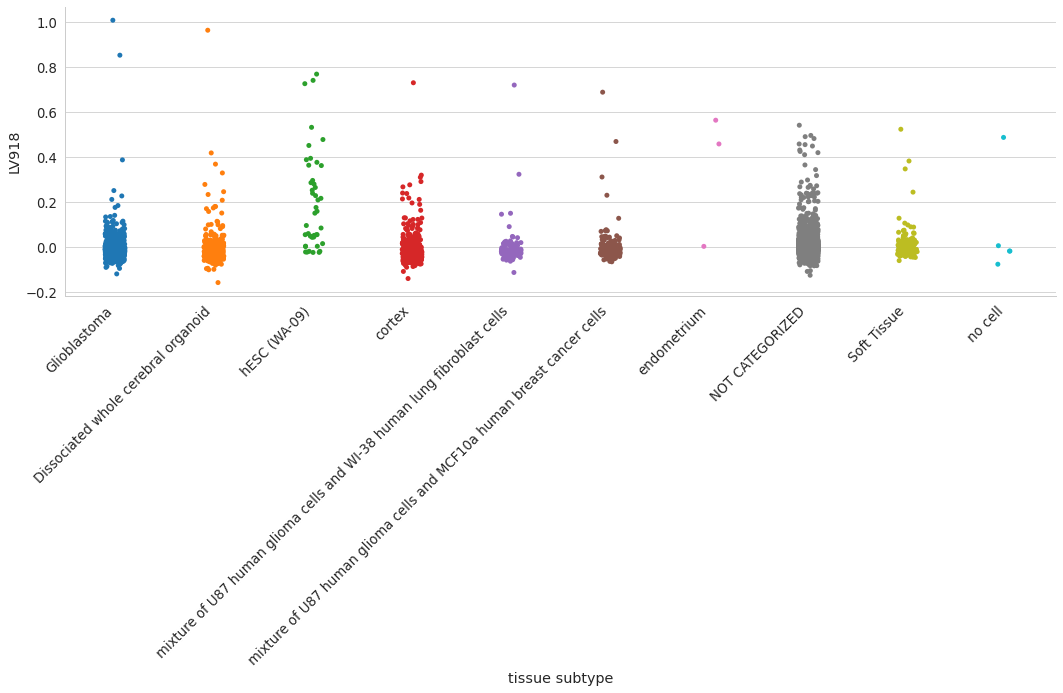

In [38]:
with sns.plotting_context("paper", font_scale=1.5), sns.axes_style("whitegrid"):
    sns.catplot(
        data=final_plot_data,
        y=LV_NAME,
        x=SELECTED_ATTRIBUTES[0],
        order=attr_order,
        kind="strip",
        height=5,
        aspect=3,
    )
    plt.xticks(rotation=45, horizontalalignment="right")

    # You can save the figure if you uncomment the code below
    # the figure will be created under ${DATA_FOLDER}/results/demo

    plt.savefig(
        OUTPUT_CELL_TYPE_FILEPATH,
        bbox_inches="tight",
        facecolor="white",
    )

# Debug

Now that you have the figure for your LV, you can debug some things.
For example, you'll see above that some samples are "NOT CATEGORIZED".
Let's see which are those:

In [38]:
with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None
):
    _tmp = final_plot_data[
        final_plot_data[SELECTED_ATTRIBUTES[0]].str.contains("Detroit")
    ]
    display(_tmp.head(20))

cell line     LV874
project   run                              
SRP057205 SRR1975480  Detroit 551  7.145822
          SRR1975479  Detroit 551  7.145625
          SRR1975494  Detroit 551  0.920045
          SRR1975493  Detroit 551  0.919606
          SRR1975455  Detroit 551  0.528382
          SRR1975456  Detroit 551  0.527711
          SRR1975473  Detroit 551  0.480429
          SRR1975474  Detroit 551  0.479731
          SRR1975457  Detroit 551  0.417292
          SRR1975458  Detroit 551  0.416320
          SRR1975477  Detroit 551  0.409184
          SRR1975478  Detroit 551  0.408183
          SRR1975504  Detroit 551  0.365405
          SRR1975503  Detroit 551  0.361580
          SRR1975459  Detroit 551  0.237731
          SRR1975460  Detroit 551  0.236578
          SRR1975490  Detroit 551  0.233294
          SRR1975489  Detroit 551  0.231456
          SRR1975475  Detroit 551  0.193915
          SRR1975476  Detroit 551  0.191678

We don't have information about cell type/tissue for these.
But we can manually go to the URL showed before and check out.
For example, for `SRP015360` we can open our browser with this URL:
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP057205, and see that the samples were taken from neutrophils.

If you need to see which information is provided by each SRP, you can again use the code below:

In [39]:
# what is there in these projects?
lv_data.loc[["SRP057205"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(60)

cell line gfp cd13 ssea4 tra160     LV874
project   run                                                    
SRP057205 SRR1975480  Detroit 551   +    +     +     NA  7.145822
          SRR1975479  Detroit 551   +    +     +     NA  7.145625
          SRR1975494  Detroit 551   -   NA     +      +  0.920045
          SRR1975493  Detroit 551   -   NA     +      +  0.919606
          SRR1975455  Detroit 551  NA   NA    NA     NA  0.528382
          SRR1975456  Detroit 551  NA   NA    NA     NA  0.527711
          SRR1975463           H1  NA   NA    NA     NA  0.522837
          SRR1975464           H1  NA   NA    NA     NA  0.521473
          SRR1975473  Detroit 551   +    +    NA     NA  0.480429
          SRR1975474  Detroit 551   +    +    NA     NA  0.479731
          SRR1975457  Detroit 551  NA   NA    NA     NA  0.417292
          SRR1975458  Detroit 551  NA   NA    NA     NA  0.416320
          SRR1975477  Detroit 551   +    +     -     NA  0.409184
          SRR1975478  Detroit 551   +    +     -     NA  0.408183
          SRR1975504  Detroit 551   -   NA     +      +  0.365405
          SRR1975503  Detroit 551   -   NA     +      +  0.361580
          SRR1975465           H9  NA   NA    NA     NA  0.319867
          SRR1975466           H9  NA   NA    NA     NA  0.319864
          SRR1975459  Detroit 551  NA   NA    NA     NA  0.237731
          SRR1975460  Detroit 551  NA   NA    NA     NA  0.236578
          SRR1975490  Detroit 551   +   NA     +      -  0.233294
          SRR1975489  Detroit 551   +   NA     +      -  0.231456
          SRR1975475  Detroit 551   +    -     -     NA  0.193915
          SRR1975476  Detroit 551   +    -     -     NA  0.191678
          SRR1975471  Detroit 551   +    +    NA     NA  0.190481
          SRR1975472  Detroit 551   +    +    NA     NA  0.190401
          SRR1975487  Detroit 551   -   NA     +      -  0.185547
          SRR1975468         PGP1  NA   NA    NA     NA  0.183946
          SRR1975467         PGP1  NA   NA    NA     NA  0.182994
          SRR1975488  Detroit 551   -   NA     +      -  0.178383
          SRR1975481  Detroit 551   +    -     +     NA  0.142276
          SRR1975482  Detroit 551   +    -     +     NA  0.141954
          SRR1975469  Detroit 551   +    -    NA     NA  0.089477
          SRR1975470  Detroit 551   +    -    NA     NA  0.088974
          SRR1975499  Detroit 551   -   NA     +      -  0.073286
          SRR1975500  Detroit 551   -   NA     +      -  0.072839
          SRR1975495  Detroit 551   +   NA     -      -  0.071876
          SRR1975496  Detroit 551   +   NA     -      -  0.071729
          SRR1975491  Detroit 551   -   NA     +      +  0.061450
          SRR1975492  Detroit 551   -   NA     +      +  0.061157
          SRR1975485  Detroit 551   +   NA     -      -  0.051326
          SRR1975486  Detroit 551   +   NA     -      -  0.049432
          SRR1975453  Detroit 551  NA   NA    NA     NA  0.049123
          SRR1975454  Detroit 551  NA   NA    NA     NA  0.049008
          SRR1975501  Detroit 551   -   NA     +      +  0.044060
          SRR1975502  Detroit 551   -   NA     +      +  0.043984
          SRR1975498  Detroit 551   +   NA     +      -  0.038335
          SRR1975497  Detroit 551   +   NA     +      -  0.038302
          SRR1975484  Detroit 551   -    -     +     NA  0.018635
          SRR1975483  Detroit 551   -    -     +     NA  0.018549
          SRR1975505  Detroit 551  NA   NA    NA     NA  0.010443
          SRR1975506  Detroit 551  NA   NA    NA     NA  0.007838
          SRR1975507  Detroit 551  NA   NA    NA     NA  0.004690
          SRR1975508  Detroit 551  NA   NA    NA     NA  0.000223
          SRR1975462  Detroit 551  NA   NA    NA     NA -0.018291
          SRR1975461  Detroit 551  NA   NA    NA     NA -0.018472

Now you can go back to section `Standardize cell type names` in this notebook and adjust according to this findings to improve the figure.
Once you are happy, you can remove the `NOT CATEGORIZED` items by uncommenting the code in `Delete samples with no tissue/cell type information`.